#cross checking the 3 way split 
import pandas as pd
import os

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "Processed")

for fname in ["X_train_scaled_original.csv", "y_train_original.csv", "X_val.csv", "y_val.csv", "X_test.csv", "y_test.csv"]:
    path = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(path)
    print(f"{fname}: shape = {df.shape}")

# Hyperparameter Tuning — Fraud Detection Models

This notebook performs controlled hyperparameter optimisation of the strongest baseline models identified in the previous modelling stage.

**Objective:** Improve minority-class ranking performance under extreme class imbalance, using a methodologically sound cross-validation setup.

**Optimization Strategy:**
- Models tuned: Random Forest, XGBoost
- Optimisation metric: PR-AUC (Average Precision)
- Secondary reference: ROC-AUC
- Cross-validation: StratifiedKFold (to preserve class proportions)
- Data used: training set only (model fitting); validation set (model comparison 
  and sanity checks)
- No test-set usage in this notebook — the test set is reserved exclusively for 
  final, one-time reporting in Notebook 5
- No threshold tuning

**Methodology note — SMOTE inside the cross-validation pipeline:**
An earlier version of this notebook applied SMOTE to the training data once, upfront, before cross-validation. This produced suspiciously high CV PR-AUC scores (>0.999), which on investigation turned out to be caused by synthetic minority-class points leaking across CV folds — a synthetic fraud point generated from a real fraud case in one fold could be validated against in another fold, since it is by construction a close neighbor of its source point. This inflated cross-validated performance without reflecting genuine generalization ability.

This version corrects that by moving SMOTE inside an `imblearn` pipeline, so that resampling is fit fresh within each individual training fold during cross-validation, and never influences the corresponding held-out fold. This is the standard, correct approach when combining SMOTE with cross-validation.

In [2]:
# 1. Imports for Hyperparameter Tuning Notebook

# System & OS
import os
import sys
import json
import pickle
import warnings
from datetime import datetime

# Data
import numpy as np
import pandas as pd

#modeling
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
#from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

#vizualisation
import matplotlib.pyplot as plt

# Suppress XGBoost warnings during fitting
warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

### 2. Project Paths, Directories, and Reproducibility

In [3]:
# 2. Paths, directories & random seed

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Data paths
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

# Output directories
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
PLOTS_DIR = os.path.join(PROJECT_ROOT, "plots")

# Create directories if they don't exist
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Project directories ready.")
print("PROJECT_ROOT:", PROJECT_ROOT)

Project directories ready.
PROJECT_ROOT: C:\Users\mail2\OneDrive\Desktop\UNSW\git_projects\fraud_detection


### 3. Load Preprocessed Data

The original, scaled, **pre-SMOTE** training set and the validation set (generated in Notebook 2) are loaded here. SMOTE is deliberately **not** applied at this stage — it is instead applied inside the cross-validation pipeline in Section 5, ensuring no synthetic data point can leak across CV fold boundaries.

In [4]:
# 3. Load preprocessed data (original, pre-SMOTE training data + validation)
X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train_scaled_original.csv"))
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train_original.csv")).squeeze()

X_val = pd.read_csv(os.path.join(DATA_DIR, "X_val.csv"))
y_val = pd.read_csv(os.path.join(DATA_DIR, "y_val.csv")).squeeze()

print("Train (original, pre-SMOTE) and validation datasets loaded.")
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)

Train (original, pre-SMOTE) and validation datasets loaded.
Train shape: (170883, 30) (170883,)
Validation shape: (56962, 30) (56962,)


### 4. Cross-Validation Strategy Scoring Metric

- StratifiedKFold with 3 folds to preserve class imbalance
- PR-AUC (`average_precision`) selected as the primary metric for minority-class ranking

In [6]:
# 4. Cross-validation strategy & scoring
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Primary optimisation metric for tuning
SCORING = "average_precision"


### 5. Models Selected for Hyperparameter Tuning

- Only tree-based ensemble models are tuned, due to strong baseline performance
- Random Forest and XGBoost are wrapped in `imblearn` Pipelines, with SMOTE as an internal pipeline step rather than pre-applied to saved data
- This ensures that during `RandomizedSearchCV`'s internal cross-validation, SMOTE is fit fresh within each fold's training portion only — no synthetic point derived from one fold's real fraud cases can appear in another fold's validation split
- Linear and neural network models excluded to reduce computation and instability on imbalanced data

In [7]:
# 5. Models wrapped with SMOTE INSIDE the pipeline
models_to_tune = {
    "RandomForest": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    
    "XGBoost": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

### 6. Hyperparameter Search Spaces

- RandomizedSearchCV parameter grids defined for each model
- Parameter names use Pipeline format (`model__param`) to support scikit-learn pipelines
- Grids are designed to explore influential hyperparameters without excessive compute

These grids will be used in the subsequent tuning step.


In [8]:
# 6.
# Random Forest search space (Pipeline format)
rf_param_dist = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__class_weight": ["balanced"]
}

# XGBoost search space (Pipeline format)
xgb_param_dist = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 6, 10],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__scale_pos_weight": [1, 10, 50]
}

### Observations — Corrected Cross-Validation Results

With SMOTE correctly applied inside each cross-validation fold, CV PR-AUC 
scores are now **0.840 (Random Forest)** and **0.848 (XGBoost)** — a 
substantial and expected drop from the previous (leaked) run's 0.9999-plus 
scores. This is the intended outcome of the fix, not a regression: the model 
is now being evaluated against genuinely unseen data within each fold, rather 
than near-duplicates of its own training data.

Notably, these corrected CV scores are now much closer to the models' actual 
validation-set performance (0.795–0.815 PR-AUC, see Section 8), rather than 
the enormous, telltale gap between CV and validation performance seen 
previously. A cross-validation score that closely tracks held-out performance 
is a strong indicator that the CV procedure is now trustworthy.

### 7. Running hyperparameter tuning/ Model fitting/ Hyperparameter Optimization

- RandomizedSearchCV is applied to each model sequentially (for efficient exploration of large and influential parameter spaces, reduced computational cost and faster convergence to strong configurations)
- StratifiedKFold ensures class imbalance preservation
- n_iter is kept low for computational efficiency
- Best hyperparameters are selected based on CV performance
- Best estimator and tuning results are saved for each model
- Outputs include the best CV PR-AUC score

Tuning results are retained in `tuned_models` and `tuning_results` for reproducibility and downstream use.


In [9]:
# 7. 
tuned_models = {}
tuning_results = {}

for name, pipeline in models_to_tune.items():
    
    print(f"\nStarting tuning for {name}...\n")
    
    param_dist = rf_param_dist if name == "RandomForest" else xgb_param_dist
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=5,
        scoring=SCORING,
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=1
    )
    
    search.fit(X_train, y_train)
    
    tuned_models[name] = search.best_estimator_
    
    tuning_results[name] = {
        "best_params": search.best_params_,
        "best_cv_pr_auc": search.best_score_
    }
    
    print(f"{name} tuning complete.")
    print("Best CV PR-AUC:", search.best_score_)
    print("Best RF params:", search.best_params_)


Starting tuning for RandomForest...

Fitting 3 folds for each of 5 candidates, totalling 15 fits
RandomForest tuning complete.
Best CV PR-AUC: 0.8402295808484531
Best RF params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_depth': None, 'model__class_weight': 'balanced'}

Starting tuning for XGBoost...

Fitting 3 folds for each of 5 candidates, totalling 15 fits
XGBoost tuning complete.
Best CV PR-AUC: 0.8475930209867578
Best RF params: {'model__subsample': 0.8, 'model__scale_pos_weight': 1, 'model__n_estimators': 400, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


### 8. Validation Set Evaluation (Sanity Check)

- Tuned models are evaluated on held-out validation set using threshold-independent metrics (ROC-AUC and PR-AUC)
- Confirms that cross-validated improvements translate to unseen data
- No threshold-based selection is applied here

This evaluation is not used for model selection or tuning decisions.

Results are stored in `results_df` for reporting and comparison.


In [10]:
# 8. 
evaluation_results = []

for name, model in tuned_models.items():
    
    probs = model.predict_proba(X_val)[:, 1]
    
    roc = roc_auc_score(y_val, probs)
    pr  = average_precision_score(y_val, probs)
    
    evaluation_results.append({
        "Model": name,
        "ROC-AUC": roc,
        "PR-AUC": pr
    })

results_df = pd.DataFrame(evaluation_results)
results_df

,Model,ROC-AUC,PR-AUC
0,RandomForest,0.973397,0.803008
1,XGBoost,0.967332,0.814953


### Experiment Metadata Logging

Tuning results, validation-set evaluation, random seed, and cross-validation strategy are logged to a structured JSON file for reproducibility.

In [11]:
# 10. Experiment Metadata logging
experiment_metadata = {
    "primary_metric": "PR-AUC",
    "cv_strategy": "StratifiedKFold (3 folds)",
    "random_state": RANDOM_STATE,
    "tuning_results": tuning_results,
    "validation_set_results": results_df.to_dict(orient="records")
}

with open(os.path.join(REPORTS_DIR, "experiment_latest.json"), "w") as f:
    json.dump(experiment_metadata, f, indent=4)

print("Experiment metadata saved.")

Experiment metadata saved.


### 11. Structured Evaluation Report Export

- Validation-set evaluation metrics is saved in CSV format
- Allows easy inspection, visualization, and comparison with future experiments

In [12]:
# 11. Evaluation report export
results_df.to_csv(os.path.join(REPORTS_DIR, "evaluation_latest.csv"),index=False)

print("Structured evaluation report exported.")


Structured evaluation report exported.


### Baseline vs. Tuned Model Comparison

Baseline and tuned models are compared on the validation set, with PR-AUC as the primary ranking metric and ROC-AUC as a secondary signal. Results are sorted with the top-performing model first.

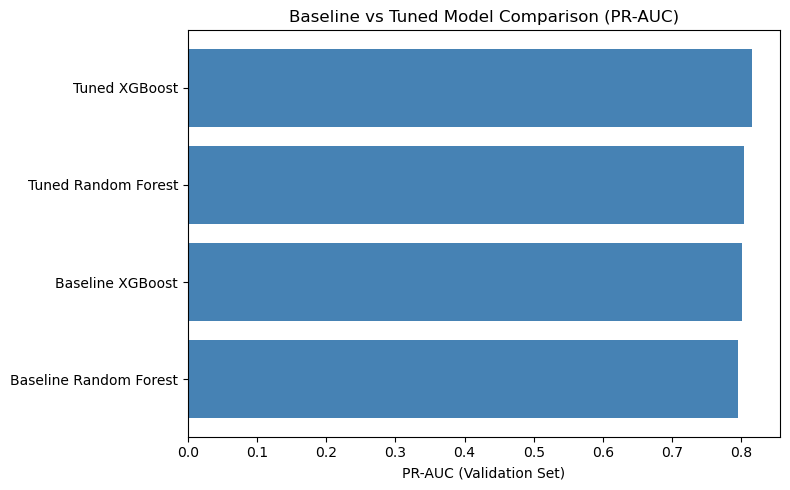

In [13]:
# 12. Load baseline results from Notebook 3
with open(os.path.join(RESULTS_DIR, "baseline_results.pkl"), "rb") as f:
    baseline_results = pickle.load(f)

# Create a DataFrame to compare baseline and tuned PR-AUC on test set
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Baseline XGBoost",
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],
    "PR-AUC (Validation Set)": [
        baseline_results["Random Forest"]["pr_auc"],
        baseline_results["XGBoost"]["pr_auc"],
        results_df.loc[results_df["Model"] == "RandomForest", "PR-AUC"].values[0],
        results_df.loc[results_df["Model"] == "XGBoost", "PR-AUC"].values[0]
    ],
    "ROC-AUC (Validation Set)": [
         baseline_results["Random Forest"]["roc_auc"],
        baseline_results["XGBoost"]["roc_auc"],
        results_df.loc[results_df["Model"] == "RandomForest", "ROC-AUC"].values[0],
        results_df.loc[results_df["Model"] == "XGBoost", "ROC-AUC"].values[0]
    ]
})

# Display sorted by PR-AUC
comparison_df = comparison_df.sort_values("PR-AUC (Validation Set)", ascending=False)
comparison_df

# Visualize baseline vs tuned comparison
plt.figure(figsize=(8, 5))
plt.barh(comparison_df["Model"], comparison_df["PR-AUC (Validation Set)"], color="steelblue")
plt.xlabel("PR-AUC (Validation Set)")
plt.title("Baseline vs Tuned Model Comparison (PR-AUC)")
plt.gca().invert_yaxis()  # highest value at top
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "baseline_vs_tuned_comparison.png"),
            dpi=300, bbox_inches="tight")
plt.show()

### Observations

Under consistent, leak-free validation-set evaluation:

- **Tuned XGBoost achieves the highest PR-AUC (0.815)**, a meaningful improvement over its own baseline (0.801) and ahead of both Random Forest variants
- Tuning produced a modest gain for Random Forest as well (0.796 → 0.803), smaller than XGBoost's improvement
- Random Forest retains a slightly higher ROC-AUC, but PR-AUC remains the primary metric given the severity of class imbalance, so this does not change the overall ranking
- Critically, this ranking is **unchanged** from before the SMOTE-leakage fix — Tuned XGBoost was, and remains, the top-performing model. The fix corrected the *trustworthiness* of the cross-validation process without changing the underlying model selection outcome, which increases confidence that this result reflects genuine model quality rather than a methodological artifact

**Tuned XGBoost is carried forward as the leading candidate into cost-sensitive threshold analysis (Notebook 5), with Random Forest retained for comparison.**

### Persist Tuned Models

The tuned model objects are saved as `tuned_models_latest.pkl`, providing a single, current reference for downstream notebooks.

In [14]:
# 13. Save tuned models (latest version only)
with open(os.path.join(MODELS_DIR, "tuned_models_latest.pkl"), "wb") as f:
    pickle.dump(tuned_models, f)

print("Tuned models saved.")

Tuned models saved.


### Future Work: Segment-Specific Fraud Models

EDA revealed a U-shaped relationship between fraud rate and transaction amount — elevated fraud at very low amounts (consistent with card-testing behavior) and again at high amounts (consistent with cash-out behavior), with a low-risk middle range. This raises the question of whether a single model can adequately represent both fraud behaviors, or whether separate models trained per value segment would perform better.

Separate models per segment is justified only if the fraud patterns are genuinely different enough that one model can't represent both well — which the EDA gives some hint of, but confirming it properly would require more analysis than the fraud rate curve alone. This is identified as a candidate for future investigation, not implemented in this iteration, given the limited number of fraud cases (492 total) available to support robust per-segment training.